In [1]:
!pip install yfinance

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
df.head()

/tmp/ipykernel_18499/2958485963.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.957992,139.439049,136.328682,137.827952,9.895373e+07
std,33.357830,33.477922,33.218687,33.351565,5.439610e+07
min,54.213608,55.211524,51.372088,55.110042,2.404830e+07
25%,120.397024,121.638013,118.864130,120.502574,6.407675e+07
50%,142.816353,144.390246,141.154860,142.666140,8.467540e+07
75%,163.195042,165.471087,161.941419,163.462858,1.155069e+08
max,196.073105,197.567574,194.974504,195.984034,4.265100e+08


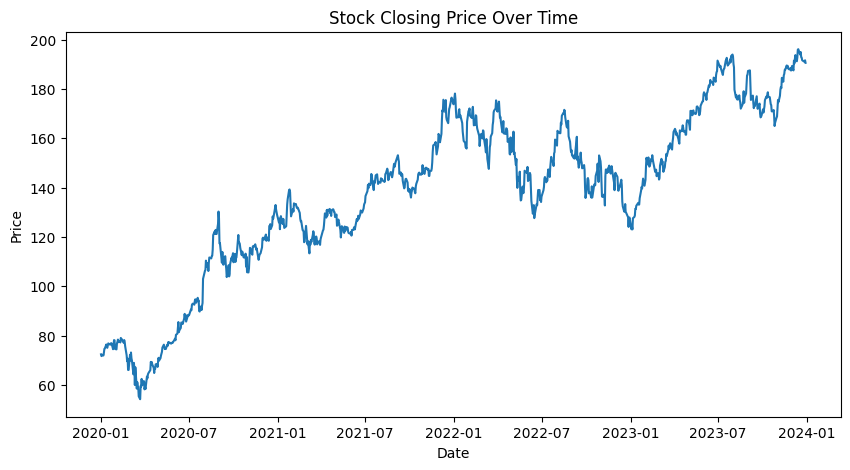

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [6]:
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

In [7]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

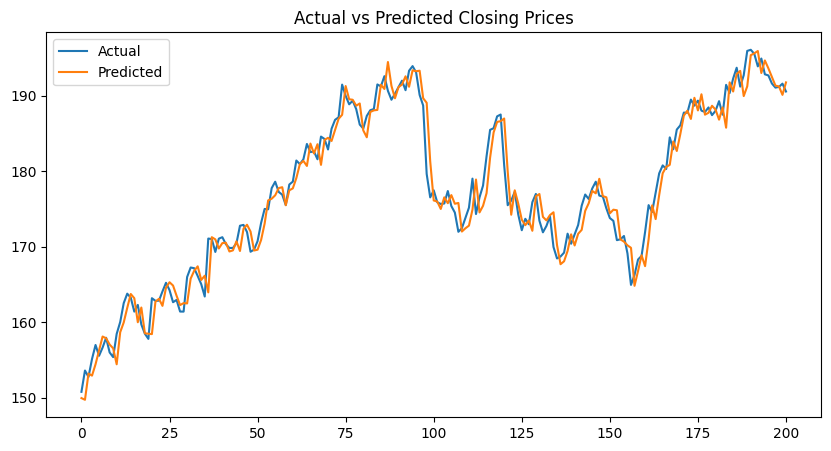

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.65422125199871
